In [1]:
import pandas as pd
import numpy as np

real_df = pd.read_csv('./real_events.csv')
virt_df = pd.read_csv('./virtual_events.csv')

# born projection
real_df['pt'] = real_df['pt_real'] + real_df['z_gluon']  # pT_projected = pT_real + z_gluon
real_df['y'] = real_df['y_real']

# combined df of real and virtual
df = pd.concat([real_df[['pt', 'y', 'weight']], virt_df[['pt', 'y', 'weight']]], ignore_index=True)

df.head()

,pt,y,weight
0,31.864740,1.188217,7.568181
1,45.011631,0.188277,3.723828
2,19.960962,1.035259,8.334504
3,11.898210,0.196120,13.693787
4,7.503392,-2.312813,17.479417


In [3]:
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

def get_scaled_coords(df):
    # returns coordinates with y scaled by 10
    pts = df['pt'].values
    ys = df['y'].values * 10
    return np.column_stack((pts, ys))

coords = get_scaled_coords(df)
tree = KDTree(coords) # pass the scaled coordinates so the distance metric is as given
weights = df['weight'].values.copy()
used = np.zeros(len(weights), dtype=bool)

# resampling loop
for i in range(len(weights)):
    if weights[i] < 0 and not used[i]:
        cell_idx = [i]
        used[i] = True
        
        # grow cell until total weight is positive
        k = 2 
        while np.sum(weights[cell_idx]) < 0:
            dist, neighbors = tree.query(coords[i], k=k)
            new_neighbor = neighbors[-1]
            
            if not used[new_neighbor]:
                cell_idx.append(new_neighbor)
                used[new_neighbor] = True
            k += 1
            
        # redistribute weights to eliminate negatives while conserving sum
        w_sum = np.sum(weights[cell_idx])
        abs_w_sum = np.sum(np.abs(weights[cell_idx]))
        weights[cell_idx] = np.abs(weights[cell_idx]) * (w_sum / abs_w_sum)

df['new_weight'] = weights

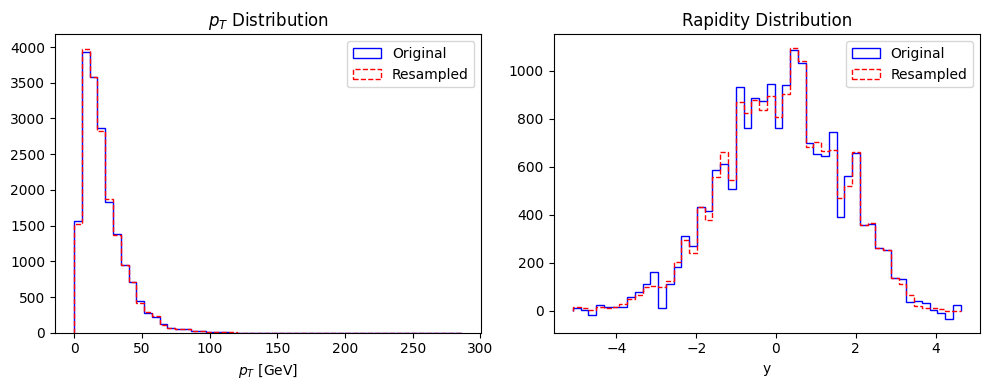

Original Total Weight: 18123.9747
Resampled Total Weight: 18123.9747
Negative weights remaining: 0


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# plot pT distribution
ax[0].hist(df['pt'], bins=50, weights=df['weight'], histtype='step', label='Original', color='blue')
ax[0].hist(df['pt'], bins=50, weights=df['new_weight'], histtype='step', ls='--', label='Resampled', color='red')
ax[0].set_title('$p_T$ Distribution')
ax[0].set_xlabel('$p_T$ [GeV]')
ax[0].legend()

# plot rapidity distribution
ax[1].hist(df['y'], bins=50, weights=df['weight'], histtype='step', label='Original', color='blue')
ax[1].hist(df['y'], bins=50, weights=df['new_weight'], histtype='step', ls='--', label='Resampled', color='red')
ax[1].set_title('Rapidity Distribution')
ax[1].set_xlabel('y')
ax[1].legend()

plt.tight_layout()
plt.show()

# Final check: Print total weight comparison
print(f"Original Total Weight: {df['weight'].sum():.4f}")
print(f"Resampled Total Weight: {df['new_weight'].sum():.4f}")
print(f"Negative weights remaining: {(df['new_weight'] < 0).sum()}")